# Ceridwen photometry and spectrum fit

- Fit one passive galaxy using both complementary datasets.

## Setup

- Use one Ceridwen kernel identifier on both machines.
- Run bounded CPU trials and full Vast.ai GPU fits.
- Keep a shorter mode for reproducible smoke testing.

In [1]:
import os
from datetime import UTC, datetime
from pathlib import Path

os.environ["JAX_ENABLE_X64"] = "1"

import astropy.units as u
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.table import Table
from scipy.special import softmax
from scipy.stats import entropy
from specutils.utils.wcs_utils import air_to_vac

from ceridwen.cosmology import age_gyr, flux_factor_maggies
from ceridwen.csp import CSPBasis_afe
from ceridwen.fit import load_result_h5, write_result_h5
from ceridwen.likelihood import (
    DiagonalGaussianLikelihood,
    DiagonalNoiseModel,
    MultiObservationLikelihood,
)
from ceridwen.model import SedModel, logsfr_ratios_to_sfh
from ceridwen.observation import Photometry, Spectrum
from ceridwen.sampler import run_sampler
from ceridwen.sampler.nested import BlackJAXNestedSamplerAdapter
from ceridwen.sampler.priors import Uniform
from ceridwen.ssps import SSPDataAfe, fetch_grid

jax.config.update("jax_enable_x64", True)
JAX_DEVICES = jax.devices()
GPU_AVAILABLE = any(device.platform == "gpu" for device in JAX_DEVICES) # true if any gpu is available
EXPECT_SINGLE_GPU = os.environ.get("CERIDWEN_EXPECT_SINGLE_GPU") == "1"
if EXPECT_SINGLE_GPU and (
    len(JAX_DEVICES) != 1 or JAX_DEVICES[0].platform != "gpu"
):
    raise RuntimeError(f"Expected one pinned GPU, found {JAX_DEVICES}")

TARGET_ID = os.environ.get("CERIDWEN_TARGET_ID", "M1_210210")
SEED = int(os.environ.get("CERIDWEN_RANDOM_SEED", "20260812"))
QUICK_TEST = os.environ.get("CERIDWEN_NOTEBOOK_QUICK") == "1" # checks env variable to decide on fast vs full run
RUN_PROFILE = "quick" if QUICK_TEST else ("gpu-full" if GPU_AVAILABLE else "cpu-trial")
DEFAULT_PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROJECT_ROOT = Path(os.environ.get("CERIDWEN_PROJECT_ROOT", DEFAULT_PROJECT_ROOT))
RESULTS_ROOT = Path(os.environ.get("CERIDWEN_RESULTS_ROOT", PROJECT_ROOT / "results"))
RUN_ID = datetime.now(UTC).strftime("%Y%m%dT%H%M%SZ")
DEFAULT_RESULT_DIR = RESULTS_ROOT / (
    f"ceridwen_integrated_photometry_spectra_{RUN_PROFILE}_{RUN_ID}"
)
RESULT_DIR = Path(os.environ.get("CERIDWEN_RESULT_DIR", DEFAULT_RESULT_DIR))
RESULT_DIR.mkdir(parents=True, exist_ok=True)
print(f"target: {TARGET_ID}")
print(f"random seed: {SEED}")
print(f"JAX devices: {JAX_DEVICES}")
print(f"result directory: {RESULT_DIR}")

target: M2_133501
random seed: 20260814
JAX devices: [CudaDevice(id=0)]
result directory: /root/cosmic-chronometers-jwst/results/ceridwen_vast_4x_nvidia_geforce_rtx_4070_super_four_galaxy_joint_full_incomplete_2026-08-26/gpu_2_m2_133501


## Data

- Read immutable LEGA-C and matched COSMOS2015 catalogues.
- Load the selected object's public one-dimensional spectrum.

In [2]:
LEGAC_PATH = PROJECT_ROOT / "data/raw/legac_dr2/legaCdr2.fits.gz"
PHOT_PATH = (
    PROJECT_ROOT / "data/raw/cosmos2015/cosmos2015_legac_dr2_photometry_1arcsec.fits"
)
SPECTRA_DIR = PROJECT_ROOT / "data/raw/legac_dr2/sp"

legac = Table.read(LEGAC_PATH) # loads data into astropy table
phot = Table.read(PHOT_PATH)

assert len(legac) == 1988
assert len(np.unique(phot["LEGAC_INDEX"])) == len(phot) # left -> number of distinct values in LEGAC_INDEX column
# verifies phot is unique
assert np.max(phot["MATCH_SEP_ARCSEC"]) < 1.0

## Passive selection

- Apply identical quality, NUVrJ, and emission-line filters.
- Require clean twelve-band photometry for joint fitting.

In [3]:
legac_frame = legac.to_pandas()
for text_column in ["SPECT_ID", "Filename"]:
    legac_frame[text_column] = legac_frame[text_column].map(
        lambda value: value.decode() if isinstance(value, bytes) else value
    )
phot_frame = phot.to_pandas().set_index("LEGAC_INDEX") # LEGAC_INDEX becomes the index column instead of data
phot_columns = [
    "Area",
    "Sat",
    "Cfl",
    "Deep",
    "Flag",
    "E(B-V)",
    "NUVMag",
    "RMag",
    "JMag",
    "Fuap3",
    "e_Fuap3",
    "FBap3",
    "e_FBap3",
    "FVap3",
    "e_FVap3",
    "Frap3",
    "e_Frap3",
    "Fipap3",
    "e_Fipap3",
    "Fzppap3",
    "e_Fzppap3",
    "FYap3",
    "e_FYap3",
    "FJap3",
    "e_FJap3",
    "FHap3",
    "e_FHap3",
    "FKsap3",
    "e_FKsap3",
    "F3.6um",
    "e_F3.6um",
    "F4.5um",
    "e_F4.5um",
]
parent = legac_frame.join(phot_frame[phot_columns], how="inner")

quality = (
    (parent["f_use"] == 1)
    & (parent["f_ppxf"] == 0)
    & (parent["f_z"] == 0)
    & (parent["f_int"] == 0)
    & (parent["SN"] > 0)
    & (parent["z"] >= 0.6)
    & (parent["z"] < 1.0)
)
valid_rest_magnitudes = (parent[["NUVMag", "RMag", "JMag"]] > -40).all(axis=1)
parent = parent[quality & valid_rest_magnitudes].copy()

nuv_r = parent["NUVMag"] - parent["RMag"]
r_j = parent["RMag"] - parent["JMag"]
nuvrj = (nuv_r > 3 * r_j + 1) & (nuv_r > 3.1)
photometric_passive = parent[nuvrj]

oii_ew = photometric_passive["OII_3727_EW"]
weak_oii = photometric_passive[(oii_ew > -5) | oii_ew.isna()]
oii_significance = (weak_oii["OII_3727_EW"] / weak_oii["OII_3727_EW_err"]).abs()
oiii_significance = (weak_oii["OIII_5007_EW"] / weak_oii["OIII_5007_EW_err"]).abs()
bona_fide_passive = weak_oii[~((oii_significance >= 3) | (oiii_significance >= 3))]

clean_photometry = (
    (bona_fide_passive["Area"] == 0)
    & (bona_fide_passive["Sat"] == 0)
    & (bona_fide_passive["Cfl"] == 1)
    & (bona_fide_passive["Flag"] == 0)
)
usable_passive = bona_fide_passive[clean_photometry]

selection_counts = pd.Series(
    {
        "matched primary spectra": len(parent),
        "NUVrJ passive": len(photometric_passive),
        "weak [OII]": len(weak_oii),
        "bona-fide passive": len(bona_fide_passive),
        "clean twelve-band photometry": len(usable_passive),
    }
)
display(selection_counts.to_frame("count"))

,count
matched primary spectra,1328
NUVrJ passive,609
weak [OII],454
bona-fide passive,349
clean twelve-band photometry,194


## Shared target

- Select one LEGA-C target; default to M1_210210.
- Fix redshift and stellar dispersion from LEGA-C measurements.

In [4]:
def load_spectrum(filename):
    if isinstance(filename, bytes):
        filename = filename.decode()
    with fits.open(SPECTRA_DIR / filename) as hdulist:
        spectrum = hdulist[1].data
        instrument_resolution = float(hdulist[0].header["SPEC_RES"])
    wave, flux, error, quality_flag = (
        spectrum[column][0] for column in ("WAVE", "FLUX", "ERR", "QUAL")
    )
    good = (quality_flag == 0) & (error > 0) & np.isfinite(flux)
    return wave, flux, error, good, instrument_resolution


target_rows = usable_passive[usable_passive["SPECT_ID"] == TARGET_ID]
if len(target_rows) != 1:
    raise ValueError(f"Expected one eligible {TARGET_ID} row, found {len(target_rows)}")
galaxy = target_rows.iloc[0]
wave_air, flux_dr2, error_dr2, good_pixel, instrument_fwhm_resolution = (
    load_spectrum(galaxy["Filename"])
)

z_catalog = float(galaxy["z"])
sigma_star = float(galaxy["SIGMA_STARS_PRIME"])
observed_break = 4000 * (1 + z_catalog)
assert wave_air[good_pixel].min() < observed_break < wave_air[good_pixel].max()

print(f"{galaxy['SPECT_ID']}  z={z_catalog:.4f}")
print(f"catalogue S/N={galaxy['SN']:.1f}")
print(f"fixed sigma*={sigma_star:.1f} km/s")
print(f"instrument FWHM resolving power={instrument_fwhm_resolution:.0f}")
print(
    f"good spectral coverage: {wave_air[good_pixel].min():.0f}-"
    f"{wave_air[good_pixel].max():.0f} angstrom"
)

M2_133501  z=0.7292
catalogue S/N=57.7
fixed sigma*=211.5 km/s
instrument FWHM resolving power=2500
good spectral coverage: 6582-9055 angstrom


## Photometric observation

- Convert twelve three-arcsecond fluxes from microjansky into maggies.
- Add the same five-percent photometric uncertainty floor.
- Reserve Subaru i+ exclusively for aperture anchoring.

In [5]:
FILTER_NAMES = [
    "cfht_megacam_us_9301",
    "subaru_suprimecam_B",
    "subaru_suprimecam_V",
    "subaru_suprimecam_rp",
    "subaru_suprimecam_ip",
    "subaru_suprimecam_zp",
    "vista_vircam_Y",
    "vista_vircam_J",
    "vista_vircam_H",
    "vista_vircam_Ks",
    "spitzer_irac_ch1",
    "spitzer_irac_ch2",
]
FILTER_LABELS = [
    "u*",
    "B",
    "V",
    "r+",
    "i+",
    "z+",
    "Y",
    "J",
    "H",
    "Ks",
    "3.6 um",
    "4.5 um",
]
FLUX_COLUMNS = [
    "Fuap3",
    "FBap3",
    "FVap3",
    "Frap3",
    "Fipap3",
    "Fzppap3",
    "FYap3",
    "FJap3",
    "FHap3",
    "FKsap3",
    "F3.6um",
    "F4.5um",
]
ERROR_COLUMNS = [f"e_{name}" for name in FLUX_COLUMNS]
UJY_TO_MAGGIES = 1e-6 / 3631.0
CGS_FNU_PER_MAGGIE = 3631e-23
PHOTOMETRY_FLOOR = 0.05
I_FILTER_INDEX = FILTER_NAMES.index("subaru_suprimecam_ip")

phot_flux = galaxy[FLUX_COLUMNS].to_numpy(dtype=float) * UJY_TO_MAGGIES
phot_error_stat = galaxy[ERROR_COLUMNS].to_numpy(dtype=float) * UJY_TO_MAGGIES
phot_uncertainty = np.hypot(
    phot_error_stat,
    PHOTOMETRY_FLOOR * np.abs(phot_flux),
)
phot_mask = np.isfinite(phot_flux) & np.isfinite(phot_uncertainty) & (phot_flux > 0)
phot_fit_mask = phot_mask.copy()
phot_fit_mask[I_FILTER_INDEX] = False

assert phot_mask.all()
assert phot_fit_mask.sum() == 11
phot_obs = Photometry(
    filters=FILTER_NAMES,
    flux=phot_flux,
    uncertainty=phot_uncertainty,
    mask=phot_fit_mask,
    name="photometry",
)
phot_obs.display()

filter_wave_eff = np.asarray(phot_obs.wave_eff)
filter_blue_edge = np.array(
    [float(filter_curve.blue_edge) for filter_curve in phot_obs.filterset.filters]
)
filter_red_edge = np.array(
    [float(filter_curve.red_edge) for filter_curve in phot_obs.filterset.filters]
)
filter_wave_xerr = np.vstack(
    [filter_wave_eff - filter_blue_edge, filter_red_edge - filter_wave_eff]
)
filter_colors = plt.cm.tab20(np.linspace(0, 1, len(FILTER_NAMES)))


def mark_filter_ranges(ax, show_labels=True):
    x_limits = ax.get_xlim()
    for index, (label, blue, red, effective, color) in enumerate(
        zip(
            FILTER_LABELS,
            filter_blue_edge,
            filter_red_edge,
            filter_wave_eff,
            filter_colors,
            strict=True,
        )
    ):
        visible_blue = max(blue, x_limits[0])
        visible_red = min(red, x_limits[1])
        if visible_blue >= visible_red:
            continue
        ax.axvspan(
            visible_blue,
            visible_red,
            facecolor=color,
            edgecolor=color,
            alpha=0.18,
            linewidth=1.0,
            zorder=0,
        )
        if show_labels:
            label_wave = (
                effective
                if visible_blue <= effective <= visible_red
                else 0.5 * (visible_blue + visible_red)
            )
            ax.text(
                label_wave,
                0.98 - 0.07 * (index % 2),
                label,
                color="0.15",
                fontsize=8,
                fontweight="semibold",
                ha="center",
                va="top",
                transform=ax.get_xaxis_transform(),
                clip_on=True,
            )
    ax.set_xlim(x_limits)


def mark_spectral_range(ax, show_label=False):
    fitted_wave = spectrum_wave[spectrum_mask]
    ax.axvspan(
        fitted_wave.min(),
        fitted_wave.max(),
        facecolor="tab:purple",
        edgecolor="tab:purple",
        alpha=0.12,
        linewidth=0.0,
        linestyle="--",
        zorder=-1,
    )
    for boundary in (fitted_wave.min(), fitted_wave.max()):
        ax.axvline(
            boundary,
            color="tab:purple",
            alpha=0.95,
            linewidth=1.5,
            linestyle="--",
            zorder=1,
        )
    if show_label:
        ax.plot(
            [],
            [],
            color="tab:purple",
            linewidth=1.5,
            linestyle="--",
            label="LEGA-C spectroscopic data range",
        )

Photometry (photometry)
  n_filters     : 12
  ndof          : 11
  wave_eff range: 3813 – 44781 Å
  filters       : cfht_megacam_us_9301, subaru_suprimecam_B, subaru_suprimecam_V, subaru_suprimecam_rp, subaru_suprimecam_ip … (+7 more)
  masked filters: 1 / 12

  #    filter                           λ_eff [Å]      flux [mag]             σ      S/N   mask   UL
  --------------------------------------------------------------------------------------------------
  0    cfht_megacam_us_9301                3813.2      1.4046e-10    1.0844e-11    12.95   True    -
  1    subaru_suprimecam_B                 4427.2      2.2032e-10    1.3770e-11    16.00   True    -
  2    subaru_suprimecam_V                 5454.9      1.0768e-09    5.9273e-11    18.17   True    -
  3    subaru_suprimecam_rp                6249.0      2.0463e-09    1.0596e-10    19.31   True    -
  4    subaru_suprimecam_ip                7645.9      5.5935e-09    2.8196e-10    19.84  False    -
  5    subaru_suprimecam_zp    

## Spectroscopic observation

- Convert the LEGA-C spectrum into observed-frame F-nu.
- Match its continuum scale to observed Subaru (i^+).
- Retain native pixels with instrument and stellar broadening.

findfont: Failed to find font weight semibold, now using 700.


Spectrum (spectrum)
  ndata         : 6166
  ndof          : 3582
  wavelength    : 5801.9 – 9501.9 Å
  resolution    : 2500.0 (fwhm convention)
  smoothtype    : R
  sigma_losvd   : 211.5 km/s
  logify        : False
  calibration   : none
  sky           : none
  noise_floor   : 0.0000
  noise model   : none
  masked pixels : 2584 / 6166

  i              λ [Å]            flux               σ   mask
  -----------------------------------------------------------
  0            5801.91      0.0000e+00      1.0000e+00  False
  1            5802.51      0.0000e+00      1.0000e+00  False
  2            5803.11      0.0000e+00      1.0000e+00  False
  3            5803.71      0.0000e+00      1.0000e+00  False
  4            5804.31      0.0000e+00      1.0000e+00  False
  5            5804.91      0.0000e+00      1.0000e+00  False
  6            5805.51      0.0000e+00      1.0000e+00  False
  7            5806.11      0.0000e+00      1.0000e+00  False
  8            5806.71      0.0000e+0

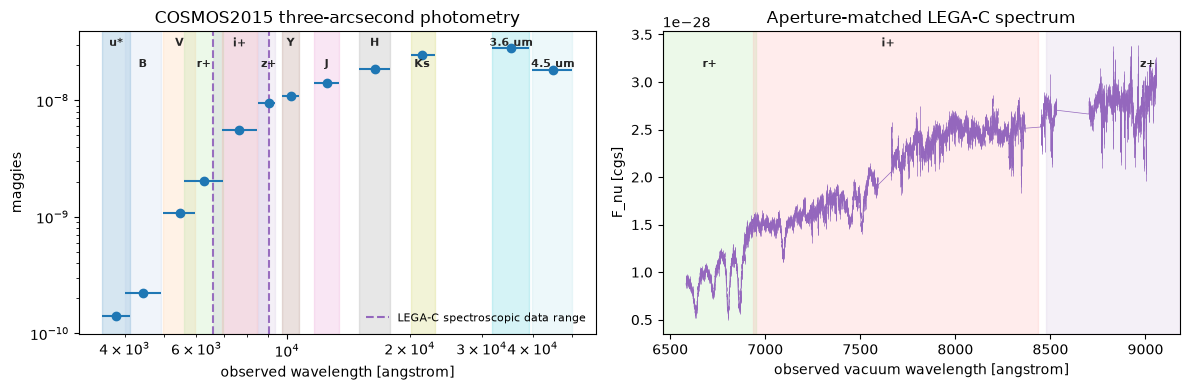

In [6]:
DR2_FLUX_UNIT = 1e-19 * u.erg / u.s / u.cm**2 / u.AA
SPECTRUM_CALIBRATION_INIT = 0.03
REST_EMISSION_LINES = [3726.0, 3728.8, 4861.3, 4958.9, 5006.8]


def flam_to_fnu_cgs(values, wavelength):
    f_lambda = values * DR2_FLUX_UNIT
    return f_lambda.to_value(
        u.erg / u.s / u.cm**2 / u.Hz,
        equivalencies=u.spectral_density(wavelength * u.AA),
    )


wave_vacuum = air_to_vac(wave_air * u.AA).to_value(u.AA)
native_flux = flam_to_fnu_cgs(flux_dr2, wave_vacuum)
native_uncertainty = flam_to_fnu_cgs(error_dr2, wave_vacuum)

telluric_vacuum = air_to_vac(np.array([7590.0, 7660.0]) * u.AA).to_value(u.AA)
anchor_good = good_pixel & np.isfinite(native_flux) & np.isfinite(native_uncertainty)
anchor_good &= ~(
    (wave_vacuum >= telluric_vacuum[0]) & (wave_vacuum <= telluric_vacuum[1])
)
for rest_wavelength in REST_EMISSION_LINES:
    line_center = rest_wavelength * (1 + z_catalog)
    velocity_offset = np.abs(wave_vacuum - line_center) / line_center * 299792.458
    anchor_good &= velocity_offset > 1500.0

anchor_flux = np.interp(
    wave_vacuum,
    wave_vacuum[anchor_good],
    native_flux[anchor_good],
)
anchor_uncertainty = np.interp(
    wave_vacuum,
    wave_vacuum[anchor_good],
    native_uncertainty[anchor_good],
)
i_anchor = Photometry(
    filters=["subaru_suprimecam_ip"],
    name="i_anchor",
)
i_filter = i_anchor.filterset.filters[0]
assert wave_vacuum[anchor_good].min() < float(i_filter.blue_edge)
assert wave_vacuum[anchor_good].max() > float(i_filter.red_edge)

anchor_spectrum = Spectrum(
    wavelength=wave_vacuum,
    flux=anchor_flux,
    uncertainty=anchor_uncertainty,
    name="anchor_spectrum",
)
synthetic_i_flux = float(
    np.asarray(anchor_spectrum.synthetic_photometry(i_anchor.filterset))
)
aperture_transfer = phot_flux[I_FILTER_INDEX] / synthetic_i_flux
assert np.isfinite(aperture_transfer) and aperture_transfer > 0

scaled_native_flux = aperture_transfer * native_flux
scaled_native_uncertainty = aperture_transfer * native_uncertainty
native_valid = (
    good_pixel
    & np.isfinite(scaled_native_flux)
    & np.isfinite(scaled_native_uncertainty)
    & (scaled_native_uncertainty > 0)
)
spectrum_wave = wave_vacuum
spectrum_flux = np.nan_to_num(scaled_native_flux, nan=0.0)
spectrum_uncertainty = np.where(
    native_valid, scaled_native_uncertainty, 1.0
)
spectrum_obs = Spectrum(
    wavelength=spectrum_wave,
    flux=spectrum_flux,
    uncertainty=spectrum_uncertainty,
    mask=native_valid,
    resolution=instrument_fwhm_resolution,
    smoothtype="R",
    res_convention="fwhm",
    sigma_losvd=sigma_star,
    name="spectrum",
)
spectrum_obs.mask_lines(
    REST_EMISSION_LINES,
    dv=1500.0,
    zred=z_catalog,
)
spectrum_obs.mask_wavelength_range(*telluric_vacuum)
spectrum_mask = np.asarray(spectrum_obs.mask)

assert spectrum_obs.ndof > 3000

spectrum_obs.display()
print(f"synthetic LEGA-C i+ flux: {synthetic_i_flux:.4e} maggies")
print(f"COSMOS2015 i+ flux: {phot_flux[I_FILTER_INDEX]:.4e} maggies")
print(f"fixed photometry/spectrum transfer: {aperture_transfer:.4f}")
print("joint photometric bands: 11; i+ reserved as aperture anchor")
print(f"native good pixels: {good_pixel.sum()}")
print(f"fitted native pixels: {spectrum_obs.ndof}")
print("library resolution: schema-2.1 automatic curve")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].errorbar(
    filter_wave_eff,
    phot_flux,
    xerr=filter_wave_xerr,
    yerr=phot_uncertainty,
    fmt="o",
    color="tab:blue",
)
axes[0].set(
    xscale="log",
    yscale="log",
    xlabel="observed wavelength [angstrom]",
    ylabel="maggies",
)
axes[0].set_title("COSMOS2015 three-arcsecond photometry")
axes[1].errorbar(
    spectrum_wave[spectrum_mask],
    spectrum_flux[spectrum_mask],
    yerr=spectrum_uncertainty[spectrum_mask],
    fmt="-",
    lw=0.5,
    color="tab:purple",
)
axes[1].set(
    xlabel="observed vacuum wavelength [angstrom]",
    ylabel="F_nu [cgs]",
)
axes[1].set_title("Aperture-matched LEGA-C spectrum")
mark_filter_ranges(axes[0])
mark_spectral_range(axes[0], show_label=True)
axes[0].legend(frameon=False, fontsize=8)
mark_filter_ranges(axes[1])
plt.tight_layout()
plt.show()

## Stellar-population grid

- Load the published alpha-enhanced C3K high-resolution grid.
- Limit every SFH to the catalogue-redshift universe age.

In [7]:
grid_path = fetch_grid("amist_c3k_hr_krou_afe")
ssp = SSPDataAfe.load(grid_path)
ssp.display()

universe_age = float(age_gyr(z_catalog))
lookback_template = np.array([0.0, 0.03, 0.1, 0.3, 1.0, 3.0, 5.0, universe_age])

assert ssp.ssp_flux.shape[0] == 5
assert np.all(np.isfinite(ssp.ssp_resolution))
grid_wave = np.asarray(ssp.ssp_wave)
grid_resolving_power = np.median(grid_wave[:-1] / np.diff(grid_wave))
assert np.isclose(grid_resolving_power, 6000.0, rtol=0.01)
assert lookback_template[-1] <= 10 ** float(ssp.ssp_lg_age_gyr.max())
assert np.asarray(phot_obs.wave_eff).max() / (1 + z_catalog) < float(ssp.ssp_wave.max())

print(f"catalogue-redshift universe age: {universe_age:.3f} Gyr")
print(f"median grid pixel resolving power: R={grid_resolving_power:.0f}")
print(f"SFH nodes: {lookback_template}")

SSPDataAfe
------------------------------------------------------------------
provenance
  isochrones (isoc_type)   : MIST v2.5 (aMIST, alpha-variable)
  spectral library         : C3K v2.3 high-res (c3k_hr, vt=10 km/s)
  IMF (imf_type)           : 2
  FSPS version             : —
  schema version           : 2.1
  recorded wave_min/max    : 100.0 / 99595854.863
  build kwargs             : {'source_fits': 'ssp_final_mistv2.5_c3kv2.3vt10allfal_250722.fits', 'provider': 'M. J. Park (2025-07-22)', 'zsun_reference': 0.0185, 'feh_to_logZ': 'log10 Z = [Fe/H] + log10(Zsun)', 'imf_name': 'Kroupa'}
grids
  [alpha/Fe]               :    5 pts   [-0.2  0.   0.2  0.4  0.6]
  metallicity  log10 Z     :   13 pts   [-4.233, -1.233]  (absolute TOTAL Z, NOT Z/Zsun, NOT [Fe/H])
  age          log10(Gyr)  :  107 pts   [-4.000, +1.300]  = [0.0001, 20] Gyr
  wavelength   Angstrom    : 10992 pts   [100.0, 99595854.9]
  flux (n_afe,n_met,n_age,n_wave): (5, 13, 107, 10992)  [L_sun Hz^-1 M_sun^-1]  float64  5

catalogue-redshift universe age: 7.134 Gyr
median grid pixel resolving power: R=6000
SFH nodes: [0.         0.03       0.1        0.3        1.         3.
 5.         7.13363628]


## Joint model

- Share SFH, chemistry, dust, mass, and fixed redshift.
- Apply fixed stellar broadening through the spectrum observation.
- Sample residual fractional spectral calibration uncertainty separately.

In [8]:
N_RATIOS = len(lookback_template) - 1
Z_BOUNDS = (
    float(ssp.ssp_lgmet.min()) + 1e-4,
    float(ssp.ssp_lgmet.max()) - 1e-4,
)
AFE_BOUNDS = (float(ssp.ssp_afe.min()), float(ssp.ssp_afe.max()))
FIXED_DUST_INDEX = -0.7

csp_theta = {
    "lookback_time": jnp.asarray(lookback_template),
    "sfh": jnp.ones(len(lookback_template)),
    "Z": jnp.array([-1.85]),
    "afe": jnp.array([0.2]),
    "diffuse_tau_kc": jnp.array([0.2]),
    "diffuse_dust_index": jnp.array([FIXED_DUST_INDEX]),
}
joint_csp = CSPBasis_afe(
    ssp,
    theta=csp_theta,
    zh_const=True,
    sfh_interp="step",
    add_dust=False,
    add_diffuse_dust=True,
    add_dust_emission=False,
    add_igm=False,
    sigma_losvd_kms=0.0,
    track_zred_age=False,
    verbose=False,
)


def sfh_from_ratios(free_theta):
    return logsfr_ratios_to_sfh(
        free_theta["logsfr_ratios"],
        sfh_times_yr=np.asarray(joint_csp.sfh_times),
    )


joint_transforms = {
    "sfh": sfh_from_ratios,
    "diffuse_dust_index": lambda free_theta: jnp.array([FIXED_DUST_INDEX]),
}
joint_priors = {
    "logsfr_ratios": Uniform(low=-3.0, high=3.0),
    "Z": Uniform(low=Z_BOUNDS[0], high=Z_BOUNDS[1]),
    "afe": Uniform(low=AFE_BOUNDS[0], high=AFE_BOUNDS[1]),
    "logmass": Uniform(low=8.0, high=13.0),
    "diffuse_tau_kc": Uniform(low=0.0, high=2.0),
    "log_f_calib": Uniform(low=np.log(0.01), high=np.log(0.10)),
}
joint_initial = {
    "logsfr_ratios": jnp.zeros(N_RATIOS),
    "logmass": jnp.array([11.0]),
    "log_f_calib": jnp.array([np.log(SPECTRUM_CALIBRATION_INIT)]),
}
joint_bounds = {
    "logsfr_ratios": (-3.0, 3.0),
    "Z": Z_BOUNDS,
    "afe": AFE_BOUNDS,
    "logmass": (8.0, 13.0),
    "diffuse_tau_kc": (0.0, 2.0),
    "log_f_calib": (np.log(0.01), np.log(0.10)),
}
joint_model = SedModel(
    joint_csp,
    observations=[phot_obs, spectrum_obs],
    priors=joint_priors,
    transforms=joint_transforms,
    free_param_init=joint_initial,
    zred=z_catalog,
)

initial_photometry = np.asarray(
    joint_model.predict(joint_model.theta_init)["photometry"]
)
active_photometry = phot_fit_mask & (initial_photometry > 0) & (phot_flux > 0)
normalization_shift = np.median(
    np.log10(phot_flux[active_photometry] / initial_photometry[active_photometry])
)
joint_model.theta_init["logmass"] = (
    joint_model.theta_init["logmass"] + normalization_shift
)
initial_prediction = joint_model.predict(joint_model.theta_init)
joint_csp.check_param_ranges(joint_model.apply_transforms(joint_model.theta_init))

assert np.all(np.isfinite(np.asarray(initial_prediction["photometry"])))
assert np.all(np.isfinite(np.asarray(initial_prediction["spectrum"])))

initial_spec_ratio = np.median(
    spectrum_flux[spectrum_mask]
    / np.asarray(initial_prediction["spectrum"])[spectrum_mask]
)
print(f"joint redshift fixed at {z_catalog:.4f}")
print(f"spectrum sigma* fixed at {sigma_star:.1f} km/s")
print(f"initial logmass: {float(joint_model.theta_init['logmass'][0]):.3f}")
print(f"initial median spectrum/model ratio: {initial_spec_ratio:.3f}")

Using only diffuse dust attenuation.
Initializing DiffuseDust model...


Dust initialization complete.
Spectrum model: dust attenuation only (alpha-enhanced, no nebular)


joint redshift fixed at 0.7292
spectrum sigma* fixed at 211.5 km/s
initial logmass: 11.109
initial median spectrum/model ratio: 0.778


## Joint posterior

- Draw nested samples from every proper parameter prior.
- Use upstream convergence settings for the full GPU profile.
- Checkpoint the sampler and save the final posterior.
- Use independent photometric and spectroscopic Gaussian likelihoods.

In [9]:
if RUN_PROFILE == "quick":
    joint_settings = {
        "num_live": 16,
        "num_inner_steps": 2,
        "num_delete": 8,
        "logZ_tol": 1e4,
    }
elif RUN_PROFILE == "cpu-trial":
    joint_settings = {
        "num_live": 150,
        "num_inner_steps": 24,
        "num_delete": 75,
        "logZ_tol": -2.0,
    }
else:
    joint_settings = {
        "num_live": 300,
        "num_inner_steps": 40,
        "num_delete": 25,
        "logZ_tol": -3.0,
    }

print(f"sampler settings: {joint_settings}")
joint_adapter = BlackJAXNestedSamplerAdapter(
    priors=joint_model.priors,
    num_live=joint_settings["num_live"],
    num_inner_steps=joint_settings["num_inner_steps"],
    num_delete=joint_settings["num_delete"],
    logZ_tol=joint_settings["logZ_tol"],
    checkpoint_interval_s=1200.0,
    checkpoint_dir=str(RESULT_DIR),
    verbose=True,
)
joint_likelihood = MultiObservationLikelihood(
    keys=(phot_obs.name, spectrum_obs.name),
    likelihoods=(
        DiagonalGaussianLikelihood(),
        DiagonalGaussianLikelihood(noise_model=DiagonalNoiseModel(use_fractional=True)),
    ),
)
joint_result = run_sampler(
    joint_model,
    joint_likelihood,
    joint_adapter,
    jax.random.PRNGKey(SEED),
)
result_path = RESULT_DIR / "ceridwen_result.h5"
write_result_h5(result_path, joint_model, joint_result)
saved_result = load_result_h5(result_path)
assert saved_result.param_names == joint_result.param_names
assert saved_result.log_likelihoods.shape == joint_result.log_likelihoods.shape
print(f"saved result: {result_path}")
print(joint_result.summary())

sampler settings: {'num_live': 300, 'num_inner_steps': 40, 'num_delete': 25, 'logZ_tol': -3.0}


BlackJAX NSS  |  n_dims=12  num_live=300  num_inner_steps=40  num_delete=25


  [timing] Calling init_fn (JIT compile + eval) ...


  [timing] init_fn done    (16.6 s)  logZ=-inf  logZ_live=228746.5365


  (state type: AdaptiveNSState)
  [checkpoint] every 1200 s -> /root/cosmic-chronometers-jwst/results/ceridwen_vast_4x_nvidia_geforce_rtx_4070_super_four_galaxy_joint_full_incomplete_2026-08-26/gpu_2_m2_133501


...

NS  logZ=234121.22  ΔlogZ=-2.95: : 11250 dead [1:25:31,  2.28 dead/s]

NS  logZ=234121.22  ΔlogZ=-3.01: : 11250 dead [1:25:31,  2.28 dead/s]

NS  logZ=234121.22  ΔlogZ=-3.01: : 11250 dead [1:25:31,  2.19 dead/s]

  Converged  logZ = 234121.223  (5131.6 s,  450,000 likelihood calls)


saved result: /root/cosmic-chronometers-jwst/results/ceridwen_vast_4x_nvidia_geforce_rtx_4070_super_four_galaxy_joint_full_incomplete_2026-08-26/gpu_2_m2_133501/ceridwen_result.h5
blackjax.nss  |  n_samples=11550  ln Z = 234121.328 ± 0.350  |  n_like = 450000  |  wall = 5131.6 s


## Sampling diagnostics

- Report evidence and posterior-weight effective sample size.
- Measure information gain using normalized nested-sampling weights.

In [10]:
def diagnostic_table(result, model, bounds):
    weights = softmax(np.asarray(result.log_weights))
    rows = []
    for name, parameter_template in model.theta_init.items():
        size = int(np.size(parameter_template))
        samples = np.asarray(result.samples[name]).reshape(len(weights), size)
        for component in range(size):
            low, high = bounds[name]
            counts, _ = np.histogram(
                samples[:, component],
                bins=30,
                range=(low, high),
                weights=weights,
            )
            probabilities = (counts + 1e-12) / np.sum(counts + 1e-12)
            uniform = np.full(30, 1 / 30)
            rows.append(
                {
                    "parameter": name if size == 1 else f"{name}[{component}]",
                    "KL posterior||prior": entropy(probabilities, uniform),
                }
            )
    return pd.DataFrame(rows), weights


def equal_weight_posterior(result, weights, count, seed):
    rng = np.random.default_rng(seed)
    indices = rng.choice(len(weights), size=count, replace=True, p=weights)
    return {name: np.asarray(values)[indices] for name, values in result.samples.items()}


joint_diagnostics, joint_weights = diagnostic_table(
    joint_result,
    joint_model,
    joint_bounds,
)
display(joint_diagnostics)

joint_weight_ess = 1.0 / np.sum(joint_weights**2)
joint_diagnostics_passed = (
    np.isfinite(joint_result.log_evidence)
    and np.isfinite(joint_result.log_evidence_err)
    and joint_weight_ess >= 200
)
joint_status = (
    "diagnostics passed"
    if RUN_PROFILE == "gpu-full" and joint_diagnostics_passed
    else f"{RUN_PROFILE}: exploratory"
)
joint_posterior = equal_weight_posterior(
    joint_result,
    joint_weights,
    count=2000,
    seed=SEED + 1,
)
print("joint fit:", joint_status)
print(f"ln Z: {joint_result.log_evidence:.3f} +/- {joint_result.log_evidence_err:.3f}")
print(f"posterior-weight ESS: {joint_weight_ess:.1f}")
print(f"likelihood calls: {joint_result.n_likelihood_calls}")

,parameter,KL posterior||prior
0,Z,2.798444
1,afe,2.528195
2,diffuse_ta...,3.322428
3,logsfr_rat...,0.053840
4,logsfr_rat...,0.158004
5,logsfr_rat...,0.391538
6,logsfr_rat...,1.345846
7,logsfr_rat...,3.149324
8,logsfr_rat...,1.316915
9,logsfr_rat...,0.332148


joint fit: diagnostics passed
ln Z: 234121.328 +/- 0.350
posterior-weight ESS: 2408.8
likelihood calls: 450000


## Posterior predictive checks

- Plot both datasets against their shared posterior model.
- Include residual calibration noise only for spectral pulls.

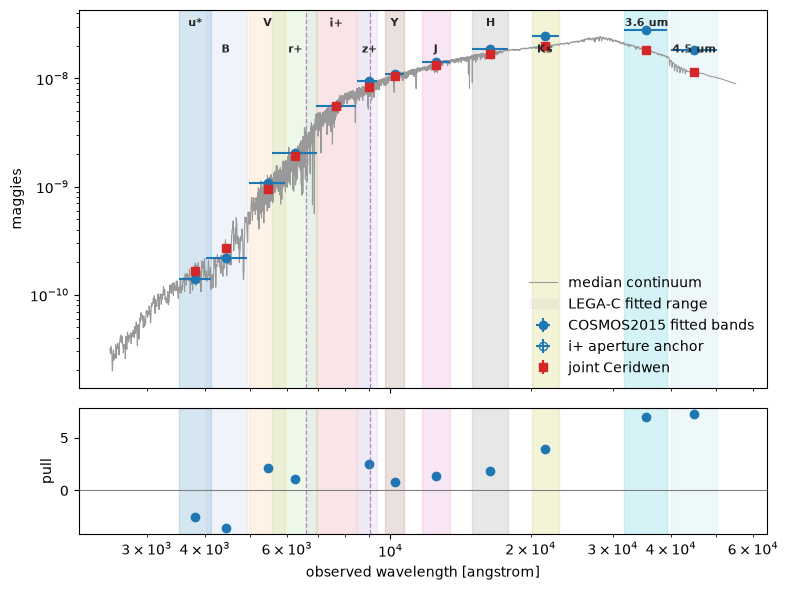

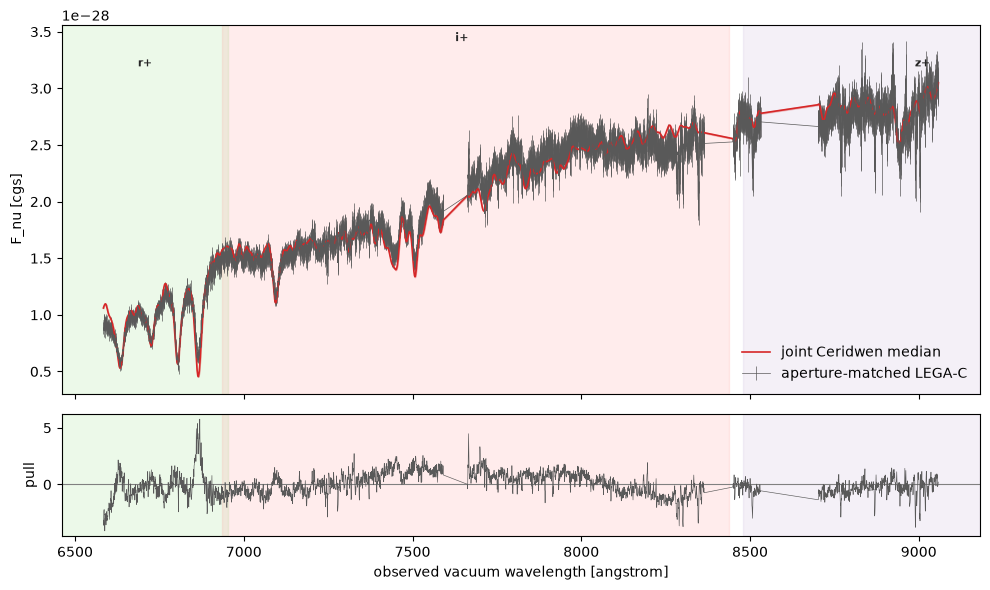

photometry chi2/datum: 13.97
spectrum chi2/bin: 1.07
joint chi2/datum: 1.11
sampled calibration floor: 4.71%
post-hoc calibrated spectrum chi2/bin: 0.91
post-hoc Chebyshev coefficients: [ 0.88183586  0.26003586 -0.146723    0.11293828]


In [11]:
def posterior_batch(samples, model, count):
    total = len(next(iter(samples.values())))
    indices = np.linspace(0, total - 1, min(count, total), dtype=int)
    batch = {}
    for name, parameter_template in model.theta_init.items():
        values = np.asarray(samples[name])[indices]
        if np.shape(parameter_template) == (1,) and values.ndim == 1:
            values = values[:, None]
        batch[name] = jnp.asarray(values)
    return batch


joint_predictions = joint_model.predict_vmap(
    posterior_batch(joint_posterior, joint_model, 200)
)
phot_predictions = np.asarray(joint_predictions["photometry"])
spectrum_predictions = np.asarray(joint_predictions["spectrum"])
phot_q16, phot_q50, phot_q84 = np.percentile(
    phot_predictions,
    [16, 50, 84],
    axis=0,
)
spec_q16, spec_q50, spec_q84 = np.percentile(
    spectrum_predictions,
    [16, 50, 84],
    axis=0,
)

median_theta = {
    name: jnp.atleast_1d(np.median(np.asarray(values), axis=0))
    for name, values in joint_posterior.items()
}
physical_theta = joint_model.apply_transforms(median_theta)
continuum = (
    np.asarray(joint_csp.get_spectrum(physical_theta))
    * 10 ** float(median_theta["logmass"][0])
    * float(flux_factor_maggies(z_catalog))
    / CGS_FNU_PER_MAGGIE
)
continuum_wave = np.asarray(joint_csp.wave) * (1 + z_catalog)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(8, 6),
    gridspec_kw={"height_ratios": [3, 1]},
    sharex=True,
)
wave_eff = filter_wave_eff
continuum_mask = (continuum_wave > 2500) & (continuum_wave < 55000)
axes[0].plot(
    continuum_wave[continuum_mask],
    continuum[continuum_mask],
    color="0.6",
    lw=0.8,
    label="median continuum",
)
axes[0].errorbar(
    wave_eff[phot_fit_mask],
    phot_flux[phot_fit_mask],
    xerr=filter_wave_xerr[:, phot_fit_mask],
    yerr=phot_uncertainty[phot_fit_mask],
    fmt="o",
    color="tab:blue",
    label="COSMOS2015 fitted bands",
)
axes[0].errorbar(
    wave_eff[I_FILTER_INDEX],
    phot_flux[I_FILTER_INDEX],
    xerr=filter_wave_xerr[:, [I_FILTER_INDEX]],
    yerr=phot_uncertainty[I_FILTER_INDEX],
    fmt="o",
    markerfacecolor="none",
    color="tab:blue",
    label="i+ aperture anchor",
)
axes[0].errorbar(
    wave_eff,
    phot_q50,
    yerr=[phot_q50 - phot_q16, phot_q84 - phot_q50],
    fmt="s",
    color="tab:red",
    label="joint Ceridwen",
)
axes[0].set(xscale="log", yscale="log", ylabel="maggies")
mark_filter_ranges(axes[0])
mark_spectral_range(axes[0], show_label=True)
axes[0].legend(frameon=False)
axes[1].axhline(0, color="0.5", lw=0.8)
axes[1].scatter(
    wave_eff[phot_fit_mask],
    (phot_flux[phot_fit_mask] - phot_q50[phot_fit_mask])
    / phot_uncertainty[phot_fit_mask],
    color="tab:blue",
)
mark_filter_ranges(axes[1], show_labels=False)
mark_spectral_range(axes[1])
axes[1].set(
    xscale="log",
    xlabel="observed wavelength [angstrom]",
    ylabel="pull",
)
plt.tight_layout()
plt.show()

calibration_fraction = float(
    np.exp(np.median(np.asarray(joint_posterior["log_f_calib"])))
)
effective_spec_uncertainty = np.hypot(
    spectrum_uncertainty,
    calibration_fraction * np.abs(spec_q50),
)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(10, 6),
    gridspec_kw={"height_ratios": [3, 1]},
    sharex=True,
)
axes[0].errorbar(
    spectrum_wave[spectrum_mask],
    spectrum_flux[spectrum_mask],
    yerr=effective_spec_uncertainty[spectrum_mask],
    fmt="-",
    lw=0.5,
    color="0.35",
    label="aperture-matched LEGA-C",
)
axes[0].plot(
    spectrum_wave[spectrum_mask],
    spec_q50[spectrum_mask],
    color="tab:red",
    lw=1.2,
    label="joint Ceridwen median",
)
axes[0].fill_between(
    spectrum_wave[spectrum_mask],
    spec_q16[spectrum_mask],
    spec_q84[spectrum_mask],
    color="tab:red",
    alpha=0.25,
)
axes[0].set(ylabel="F_nu [cgs]")
axes[0].legend(frameon=False)
axes[1].axhline(0, color="0.5", lw=0.8)
axes[1].plot(
    spectrum_wave[spectrum_mask],
    (spectrum_flux[spectrum_mask] - spec_q50[spectrum_mask])
    / effective_spec_uncertainty[spectrum_mask],
    lw=0.45,
    color="0.35",
)
axes[1].set(xlabel="observed vacuum wavelength [angstrom]", ylabel="pull")
mark_filter_ranges(axes[0])
mark_filter_ranges(axes[1], show_labels=False)
plt.tight_layout()
plt.show()

phot_chi2 = np.sum(
    (
        (phot_flux[phot_fit_mask] - phot_q50[phot_fit_mask])
        / phot_uncertainty[phot_fit_mask]
    )
    ** 2
)
spectrum_chi2 = np.sum(
    (
        (spectrum_flux[spectrum_mask] - spec_q50[spectrum_mask])
        / effective_spec_uncertainty[spectrum_mask]
    )
    ** 2
)
calibration_coefficients, calibrated_median = spectrum_obs.fit_polynomial_calibration(
    spec_q50, order=3
)
calibrated_effective_uncertainty = np.hypot(
    spectrum_uncertainty,
    calibration_fraction * np.abs(np.asarray(calibrated_median)),
)
calibrated_chi2 = np.sum(
    (
        (spectrum_flux[spectrum_mask] - np.asarray(calibrated_median)[spectrum_mask])
        / calibrated_effective_uncertainty[spectrum_mask]
    )
    ** 2
)
joint_chi2 = phot_chi2 + spectrum_chi2
joint_points = phot_obs.ndof + spectrum_obs.ndof

print(f"photometry chi2/datum: {phot_chi2 / phot_obs.ndof:.2f}")
print(f"spectrum chi2/bin: {spectrum_chi2 / spectrum_obs.ndof:.2f}")
print(f"joint chi2/datum: {joint_chi2 / joint_points:.2f}")
print(f"sampled calibration floor: {100 * calibration_fraction:.2f}%")
print(
    f"post-hoc calibrated spectrum chi2/bin: {calibrated_chi2 / spectrum_obs.ndof:.2f}"
)
print(f"post-hoc Chebyshev coefficients: {calibration_coefficients}")

## Full native-spectrum comparison

- Show every native pixel used by the joint likelihood.
- Compare high-resolution absorption structure and residuals.

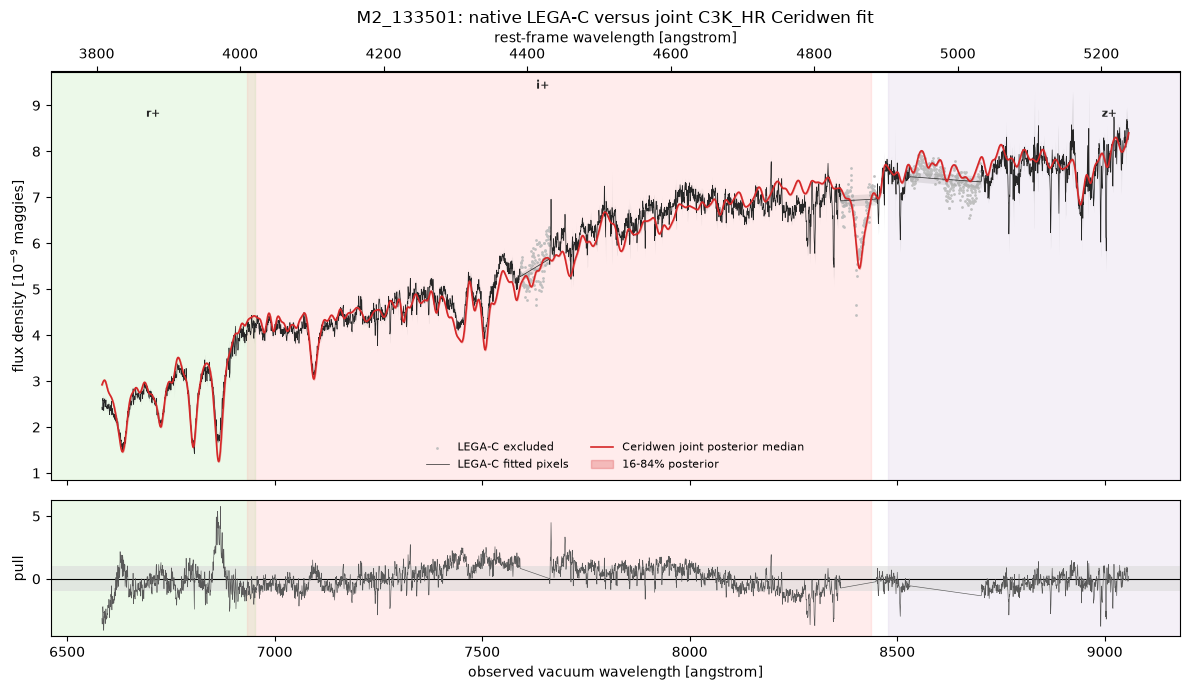

native valid pixels shown: 4121
native residual pixels after masks: 3582
native spectrum is the fitted high-resolution likelihood


In [12]:
native_plot_flux = spectrum_flux
native_plot_uncertainty = spectrum_uncertainty
native_fit_mask = spectrum_mask
native_q16, native_q50, native_q84 = spec_q16, spec_q50, spec_q84
native_effective_uncertainty = np.hypot(
    native_plot_uncertainty,
    calibration_fraction * np.abs(native_q50),
)
native_excluded_mask = native_valid & ~native_fit_mask
native_plot_scale = 1e9 / CGS_FNU_PER_MAGGIE

fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 7),
    gridspec_kw={"height_ratios": [3, 1]},
    sharex=True,
)
axes[0].scatter(
    wave_vacuum[native_excluded_mask],
    native_plot_flux[native_excluded_mask] * native_plot_scale,
    s=4,
    color="0.75",
    linewidths=0,
    label="LEGA-C excluded",
    rasterized=True,
)
axes[0].fill_between(
    wave_vacuum[native_fit_mask],
    (native_plot_flux[native_fit_mask] - native_plot_uncertainty[native_fit_mask])
    * native_plot_scale,
    (native_plot_flux[native_fit_mask] + native_plot_uncertainty[native_fit_mask])
    * native_plot_scale,
    color="0.5",
    alpha=0.18,
    linewidth=0,
)
axes[0].plot(
    wave_vacuum[native_fit_mask],
    native_plot_flux[native_fit_mask] * native_plot_scale,
    color="0.15",
    lw=0.5,
    label="LEGA-C fitted pixels",
    rasterized=True,
)
axes[0].plot(
    wave_vacuum[native_valid],
    native_q50[native_valid] * native_plot_scale,
    color="tab:red",
    lw=1.2,
    label="Ceridwen joint posterior median",
)
axes[0].fill_between(
    wave_vacuum[native_valid],
    native_q16[native_valid] * native_plot_scale,
    native_q84[native_valid] * native_plot_scale,
    color="tab:red",
    alpha=0.25,
    label="16-84% posterior",
)
axes[0].set(ylabel=r"flux density [$10^{-9}$ maggies]")
axes[0].set_title(
    f"{TARGET_ID}: native LEGA-C versus joint C3K_HR Ceridwen fit"
)
axes[0].legend(frameon=False, ncol=2, fontsize=8)
axes[1].axhspan(-1, 1, color="0.85", alpha=0.55, linewidth=0)
axes[1].axhline(0, color="k", lw=0.8)
axes[1].plot(
    wave_vacuum[native_fit_mask],
    (native_plot_flux[native_fit_mask] - native_q50[native_fit_mask])
    / native_effective_uncertainty[native_fit_mask],
    color="0.35",
    lw=0.45,
    rasterized=True,
)
axes[1].set(
    xlabel="observed vacuum wavelength [angstrom]",
    ylabel="pull",
)
mark_filter_ranges(axes[0])
mark_filter_ranges(axes[1], show_labels=False)
secondary_axis = axes[0].secondary_xaxis(
    "top",
    functions=(
        lambda observed: observed / (1 + z_catalog),
        lambda rest: rest * (1 + z_catalog),
    ),
)
secondary_axis.set_xlabel("rest-frame wavelength [angstrom]")
plt.tight_layout()
plt.show()

print(f"native valid pixels shown: {native_valid.sum()}")
print(f"native residual pixels after masks: {native_fit_mask.sum()}")
print("native spectrum is the fitted high-resolution likelihood")

## Population summary

- Derive mass-weighted age from every sampled nonparametric SFH.
- Report chemistry, dust, mass, calibration, and SFH uncertainty.

,parameter,median,minus,plus
0,logmass,11.140511,0.004076,0.004309
1,Z,-1.944011,0.019143,0.020162
2,afe,0.064254,0.012398,0.012703
3,diffuse_ta...,0.157970,0.010717,0.009616
4,fractional...,0.047115,0.000650,0.000659
5,mass-weigh...,2.654557,0.033906,0.034740


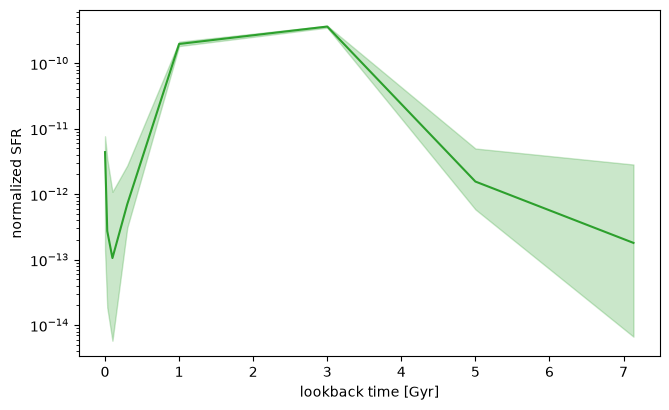

joint redshift fixed at 0.7292
fixed spectrum aperture transfer: 0.7302
joint fit status: diagnostics passed


In [13]:
def derived_sfh(samples, count=400):
    total = len(samples["logsfr_ratios"])
    indices = np.linspace(0, total - 1, min(count, total), dtype=int)
    histories = []
    ages = []
    for index in indices:
        ratios = np.asarray(samples["logsfr_ratios"])[index]
        history = np.asarray(
            logsfr_ratios_to_sfh(
                ratios,
                sfh_times_yr=lookback_template * 1e9,
            )
        )
        bin_mass = 0.5 * (history[:-1] + history[1:]) * np.diff(lookback_template) * 1e9
        bin_age = 0.5 * (lookback_template[:-1] + lookback_template[1:])
        histories.append(history)
        ages.append(np.sum(bin_mass * bin_age) / np.sum(bin_mass))
    return np.asarray(histories), np.asarray(ages)


joint_histories, joint_ages = derived_sfh(joint_posterior)
summary_rows = []
for parameter in ["logmass", "Z", "afe", "diffuse_tau_kc"]:
    q16, q50, q84 = np.percentile(
        joint_posterior[parameter],
        [16, 50, 84],
    )
    summary_rows.append(
        {
            "parameter": parameter,
            "median": q50,
            "minus": q50 - q16,
            "plus": q84 - q50,
        }
    )
q16, q50, q84 = np.percentile(
    np.exp(np.asarray(joint_posterior["log_f_calib"])),
    [16, 50, 84],
)
summary_rows.append(
    {
        "parameter": "fractional calibration floor",
        "median": q50,
        "minus": q50 - q16,
        "plus": q84 - q50,
    }
)
q16, q50, q84 = np.percentile(joint_ages, [16, 50, 84])
summary_rows.append(
    {
        "parameter": "mass-weighted age [Gyr]",
        "median": q50,
        "minus": q50 - q16,
        "plus": q84 - q50,
    }
)
summary = pd.DataFrame(summary_rows)
display(summary)

q16, q50, q84 = np.percentile(joint_histories, [16, 50, 84], axis=0)
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(lookback_template, q50, color="tab:green")
ax.fill_between(
    lookback_template,
    q16,
    q84,
    color="tab:green",
    alpha=0.25,
)
ax.set(
    yscale="log",
    xlabel="lookback time [Gyr]",
    ylabel="normalized SFR",
)
plt.show()

print(f"joint redshift fixed at {z_catalog:.4f}")
print(f"fixed spectrum aperture transfer: {aperture_transfer:.4f}")
print(f"joint fit status: {joint_status}")

## Interpretation

- Joint constraints remain one-object exploratory evidence.
- The i+ anchor is excluded from the joint likelihood.
- The fixed aperture transfer remains a model assumption.
- Do not propagate this age into cosmological inference yet.

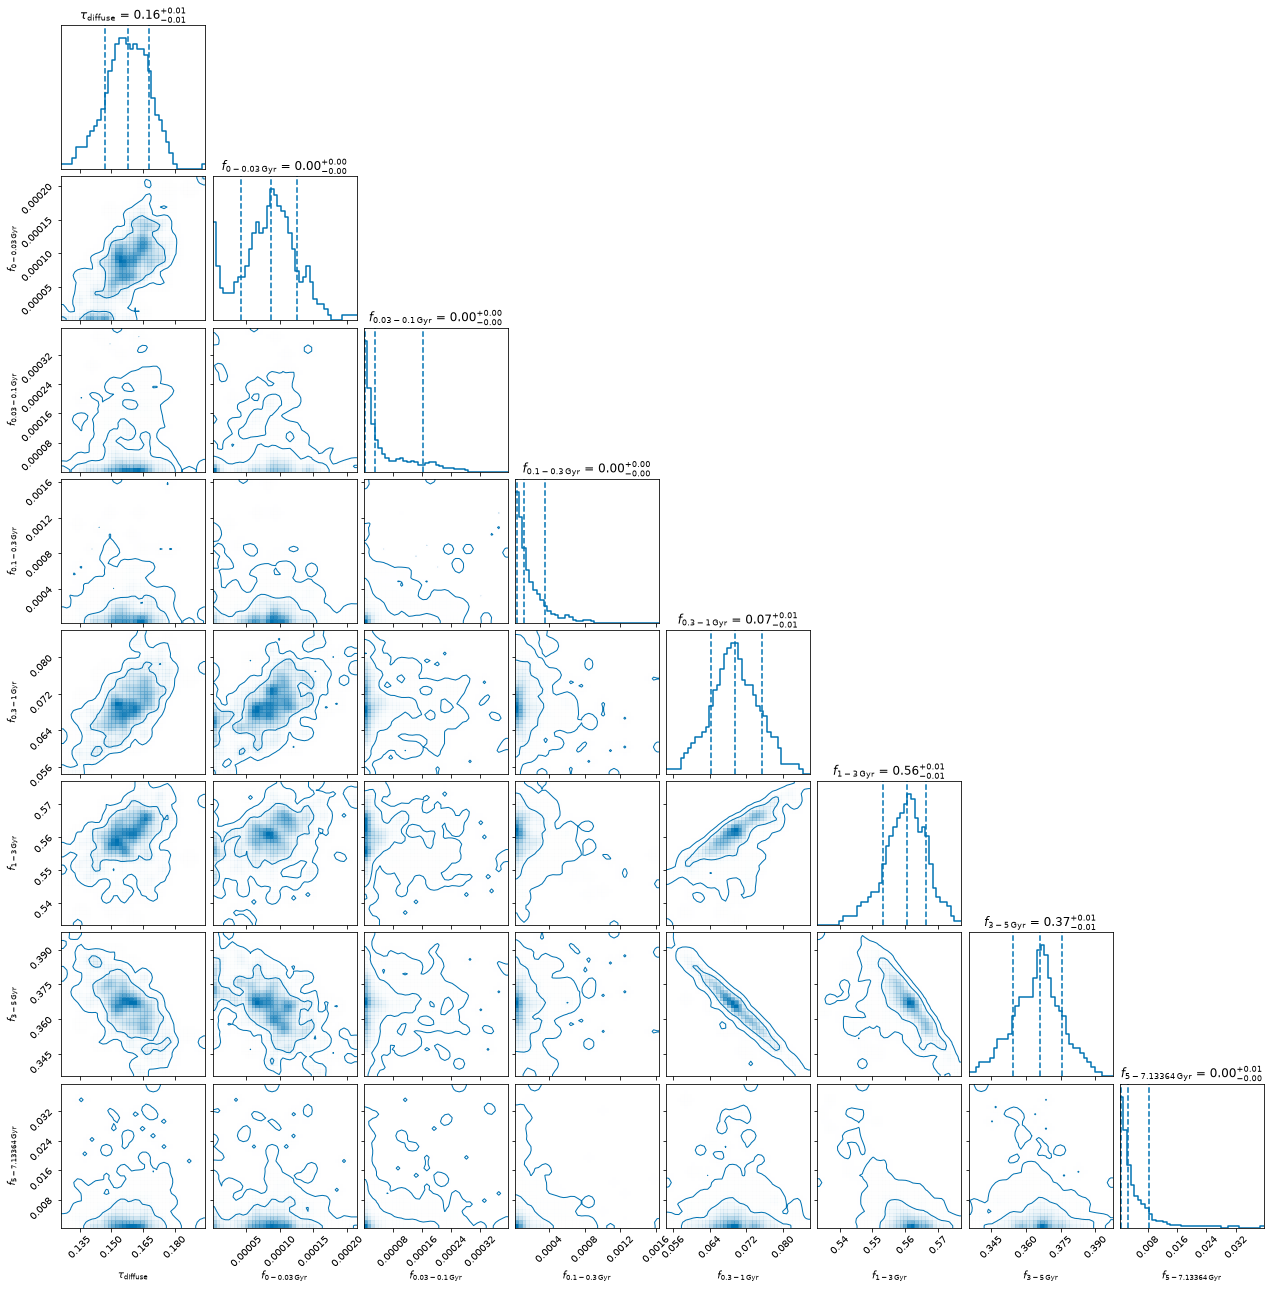

Spearman $\tau_{\mathrm{diffuse}}$ vs $f_{0-0.03\,\mathrm{Gyr}}$: +0.64
Spearman $\tau_{\mathrm{diffuse}}$ vs $f_{0.03-0.1\,\mathrm{Gyr}}$: +0.08
Spearman $\tau_{\mathrm{diffuse}}$ vs $f_{0.1-0.3\,\mathrm{Gyr}}$: -0.02
Spearman $\tau_{\mathrm{diffuse}}$ vs $f_{0.3-1\,\mathrm{Gyr}}$: +0.63
Spearman $\tau_{\mathrm{diffuse}}$ vs $f_{1-3\,\mathrm{Gyr}}$: +0.40
Spearman $\tau_{\mathrm{diffuse}}$ vs $f_{3-5\,\mathrm{Gyr}}$: -0.62
Spearman $\tau_{\mathrm{diffuse}}$ vs $f_{5-7.13364\,\mathrm{Gyr}}$: +0.08


In [ ]:
# Dust parameters against every SFH bin.
# Output added from the saved posterior by scripts/add_dust_sfh_corner.py. No refit.